In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/wheat.csv")

df

,Date,price
0,2000-01-01 00:00:00,180.8
1,2000-02-01 00:00:00,180.7
2,2000-03-01 00:00:00,180.3
3,2000-04-01 00:00:00,179.8
4,2000-05-01 00:00:00,178.4
...,...,...
277,2023-02-01 00:00:00,196.8
278,2023-03-01 00:00:00,187.1
279,2023-04-01 00:00:00,186.4
280,2023-05-01 00:00:00,184.9


<Axes: >

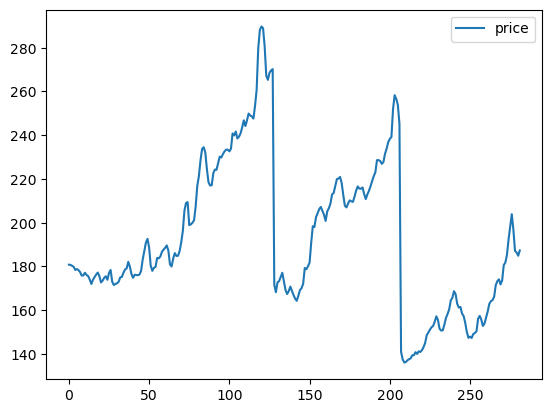

In [3]:
df.plot()

<Axes: >

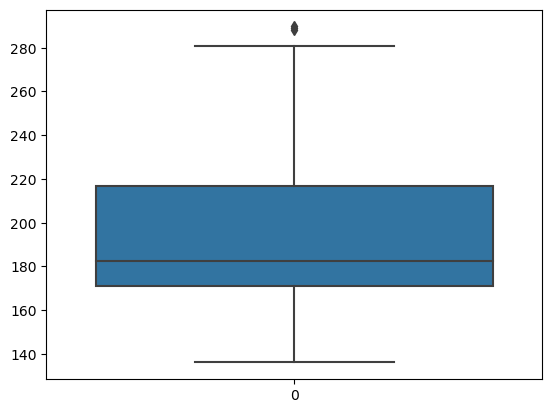

In [4]:
sn.boxplot(df['price'])

In [5]:
t=kpss(df['price'],'ct')
t

/var/folders/35/vcbg9sn9479dqrdl_3fgrrkh0000gn/T/ipykernel_43309/1514378212.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  t=kpss(df['price'],'ct')


(0.30667012535484883,
 0.01,
 10,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

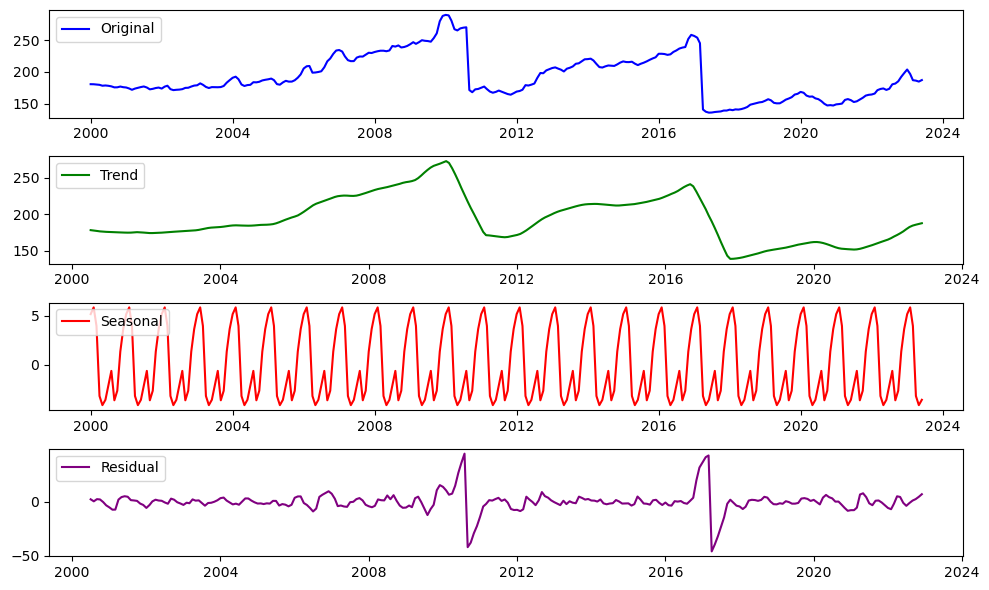

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [75]:
df=pd.read_csv("DATA/Backup/wheat.csv")

In [76]:
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))

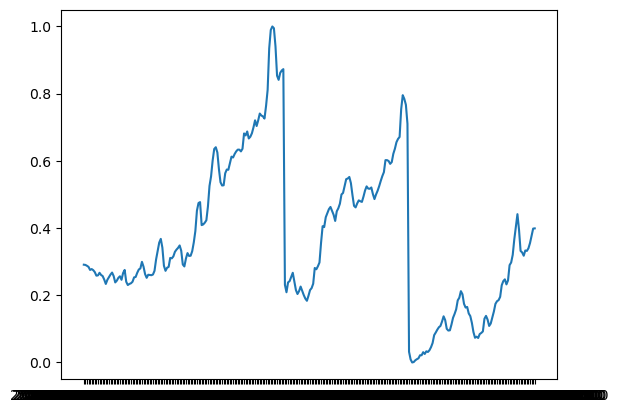

In [77]:
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['price'])

In [78]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns
shift=3
for i in range(shift):
    df['target-'+str(i+1)] = df['price'].shift(i+1)
#df['target-1'] = df['price'].shift(1)
#df['target-2'] = df['price'].shift(2)
#df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)

In [79]:
d=df[shift:]
d

,Date,price,target-1,target-2,target-3
3,2000-04-01 00:00:00,0.284505,0.287760,0.290365,0.291016
4,2000-05-01 00:00:00,0.275391,0.284505,0.287760,0.290365
5,2000-06-01 00:00:00,0.277995,0.275391,0.284505,0.287760
6,2000-07-01 00:00:00,0.274740,0.277995,0.275391,0.284505
7,2000-08-01 00:00:00,0.268880,0.274740,0.277995,0.275391
...,...,...,...,...,...
283,2023-08-01 00:00:00,0.339844,0.332031,0.333333,0.317708
284,2023-09-01 00:00:00,0.355469,0.339844,0.332031,0.333333
285,2023-10-01 00:00:00,0.376953,0.355469,0.339844,0.332031
286,2023-11-01 00:00:00,0.398438,0.376953,0.355469,0.339844


In [80]:
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 1:-1]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, -1]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)

dates.shape, X.shape, y.shape

((285,), (285, 3, 1), (285,))

In [81]:
#y

In [82]:
#dates
#X
#y

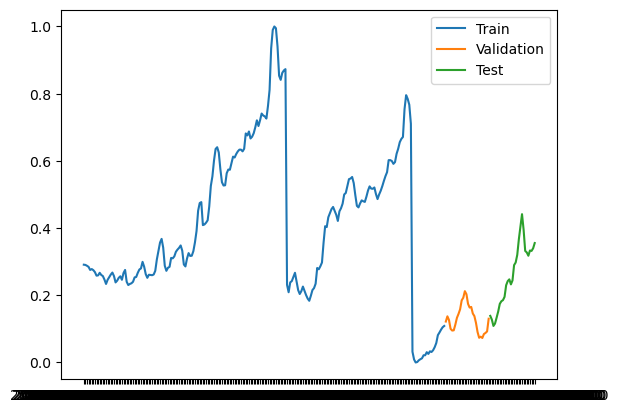

In [83]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [84]:
X_train.shape,

((228, 3, 1),)

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

#early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min')

model = Sequential([layers.Input((shift, 1)),
                    #layers.GRU(64),
                    #layers.LSTM(64),
                    layers.LSTM(64, return_sequences=True),
                    layers.LSTM(64),
                    #layers.Bidirectional(layers.LSTM(64)),
                    #layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
                    #layers.Flatten(),
                    #layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)
                   ])

model.compile(loss='mse', 
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=160)

Epoch 1/160
8/8 [==============================] - 1s 40ms/step - loss: 0.1808 - mean_absolute_error: 0.3680 - val_loss: 0.0029 - val_mean_absolute_error: 0.0418
Epoch 2/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0858 - mean_absolute_error: 0.2360 - val_loss: 0.0139 - val_mean_absolute_error: 0.1134
Epoch 3/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0214 - mean_absolute_error: 0.1127 - val_loss: 0.0633 - val_mean_absolute_error: 0.2500
Epoch 4/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0257 - mean_absolute_error: 0.1344 - val_loss: 0.0246 - val_mean_absolute_error: 0.1539
Epoch 5/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0184 - mean_absolute_error: 0.1018 - val_loss: 0.0132 - val_mean_absolute_error: 0.1110
Epoch 6/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0150 - mean_absolute_error: 0.0866 - val_loss: 0.0197 - val_mean_absolute_error: 0.1374
Epoch 7/160
8/8 [================

8/8 [==============================] - 0s 3ms/step - loss: 0.0074 - mean_absolute_error: 0.0401 - val_loss: 0.0017 - val_mean_absolute_error: 0.0336
Epoch 52/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0074 - mean_absolute_error: 0.0403 - val_loss: 0.0022 - val_mean_absolute_error: 0.0403
Epoch 53/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0074 - mean_absolute_error: 0.0403 - val_loss: 0.0013 - val_mean_absolute_error: 0.0296
Epoch 54/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0072 - mean_absolute_error: 0.0401 - val_loss: 8.2898e-04 - val_mean_absolute_error: 0.0249
Epoch 55/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0071 - mean_absolute_error: 0.0388 - val_loss: 0.0014 - val_mean_absolute_error: 0.0308
Epoch 56/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0069 - mean_absolute_error: 0.0363 - val_loss: 0.0011 - val_mean_absolute_error: 0.0279
Epoch 57/160
8/8 [===================

Epoch 101/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0045 - mean_absolute_error: 0.0253 - val_loss: 6.2570e-04 - val_mean_absolute_error: 0.0210
Epoch 102/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0044 - mean_absolute_error: 0.0250 - val_loss: 7.6260e-04 - val_mean_absolute_error: 0.0232
Epoch 103/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0043 - mean_absolute_error: 0.0247 - val_loss: 7.4737e-04 - val_mean_absolute_error: 0.0230
Epoch 104/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0043 - mean_absolute_error: 0.0251 - val_loss: 4.0476e-04 - val_mean_absolute_error: 0.0171
Epoch 105/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0044 - mean_absolute_error: 0.0278 - val_loss: 7.4985e-04 - val_mean_absolute_error: 0.0230
Epoch 106/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0043 - mean_absolute_error: 0.0244 - val_loss: 7.0366e-04 - val_mean_absolute_error: 0.022

8/8 [==============================] - 0s 3ms/step - loss: 0.0041 - mean_absolute_error: 0.0231 - val_loss: 7.0969e-04 - val_mean_absolute_error: 0.0226
Epoch 151/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0041 - mean_absolute_error: 0.0230 - val_loss: 5.8883e-04 - val_mean_absolute_error: 0.0204
Epoch 152/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0042 - mean_absolute_error: 0.0231 - val_loss: 6.0378e-04 - val_mean_absolute_error: 0.0207
Epoch 153/160
8/8 [==============================] - 0s 4ms/step - loss: 0.0041 - mean_absolute_error: 0.0232 - val_loss: 4.4451e-04 - val_mean_absolute_error: 0.0176
Epoch 154/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0042 - mean_absolute_error: 0.0246 - val_loss: 5.1623e-04 - val_mean_absolute_error: 0.0191
Epoch 155/160
8/8 [==============================] - 0s 3ms/step - loss: 0.0042 - mean_absolute_error: 0.0235 - val_loss: 7.1312e-04 - val_mean_absolute_error: 0.0227
Epoch 156/16

In [94]:
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')


Training Loss: [0.004142480902373791, 0.023442281410098076]
Testing Loss: [0.0007559870718978345, 0.02288990095257759]


8/8 [==============================] - 0s 910us/step


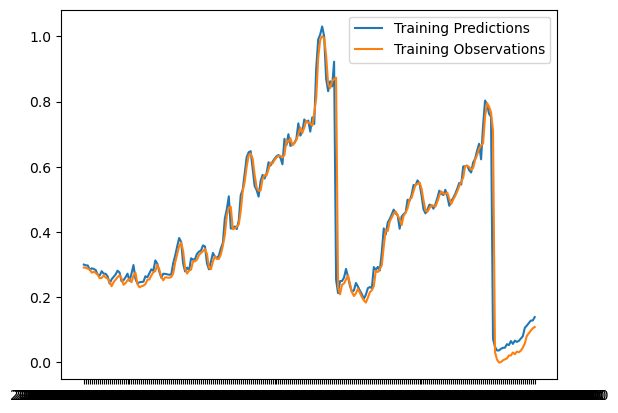

In [87]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)

#plt.plot(train_predictions)
#plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 10ms/step


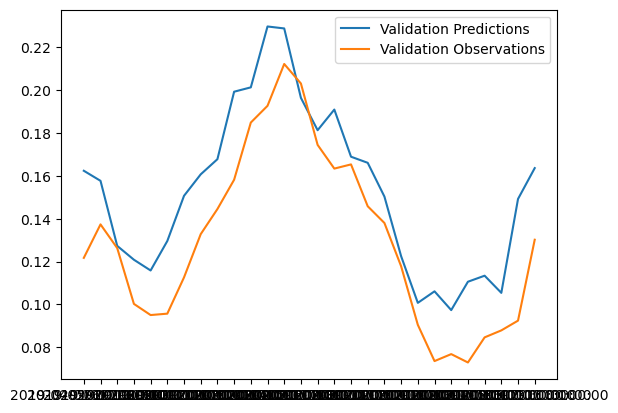

In [88]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 9ms/step


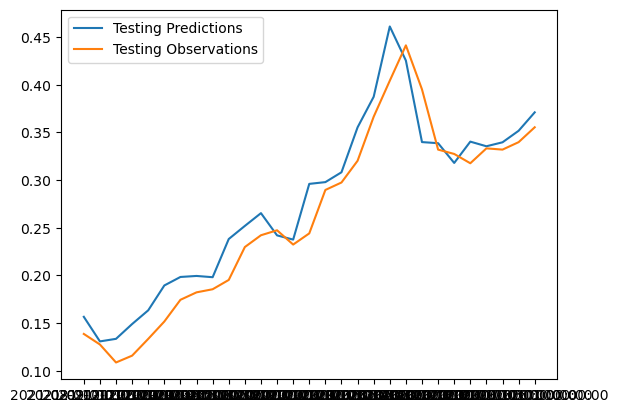

In [89]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [90]:
#test_predictions

In [91]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [92]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(train_r2)
print(val_r)
print(val_r2)
print(test_r)
print(test_r2)

Training MAE: 3.6030333042144775
Training MSE: 94.78656768798828
Val MAE: 3.6055874824523926
Val MSE: 17.174922943115234
Testing MAE: 3.3417153358459473
Testing MSE: 16.70295524597168
9.735839
0.918121266378245
4.1442637
0.5436912082511548
4.086925
0.9202732448574635


In [304]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train, train_predictions)
train_mse = mean_squared_error(y_train, train_predictions)
val_mae = mean_absolute_error(y_val, val_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
val_mse = mean_squared_error(y_val, val_predictions)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')
print(f'Testing MAE: {val_mae}')
print(f'Testing MSE: {val_mse}')

train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(val_r)
print(test_r)
print(train_r2)
print(val_r2)
print(test_r2)

Training MAE: 0.0358649305999279
Training MSE: 0.004852921701967716
Testing MAE: 0.01752581261098385
Testing MSE: 0.0005585874314419925
Testing MAE: 0.012687440030276775
Testing MSE: 0.0002566634211689234
0.06966291
0.016020719
0.023634454
0.9010968554138479
0.839117163740561
0.9370951049343192


In [61]:
model.save('wheat_lstm')

INFO:tensorflow:Assets written to: wheat_lstm/assets


INFO:tensorflow:Assets written to: wheat_lstm/assets


In [322]:
import tensorflow as tf
m1=tf.keras.models.load_model('wheat_cnn')
m1.layers[0].input_shape

(None, 3, 1)

In [332]:
test_predictions = m1.predict(X_test).flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 36ms/step
0.9370951049343192


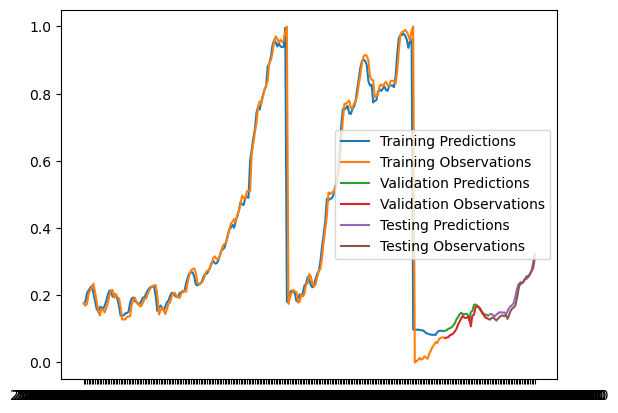

In [149]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'])



In [150]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 [==============================] - 0s 8ms/step


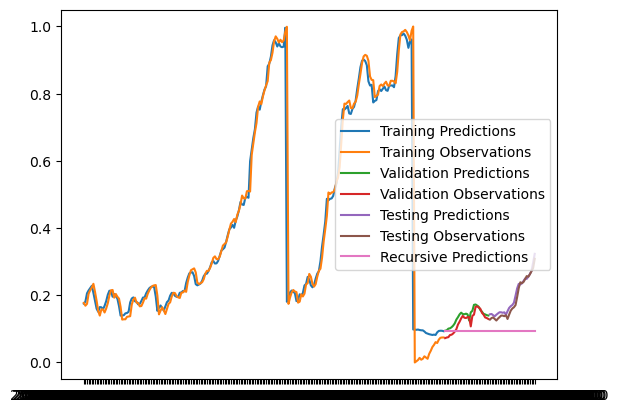

In [151]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations',
            'Recursive Predictions'])

In [72]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
# Sample DataFrame
#data = {'date': pd.date_range(start='2024-01-01', periods=100),
#        'price': np.random.rand(100)}
#df = pd.DataFrame(data)



In [63]:
# Normalize the price data
scaler = MinMaxScaler(feature_range=(0, 1))
d['price'] = scaler.fit_transform(d['Rice'].values.reshape(-1,1))

In [64]:
x=d.pop('Rice')
d

,date,price
0,2000-02-01,0.053404
1,2000-03-01,0.043292
2,2000-04-01,0.049974
3,2000-05-01,0.049490
4,2000-06-01,0.049135
...,...,...
235,2019-09-01,0.058386
236,2019-10-01,0.056683
237,2019-11-01,0.075554
238,2019-12-01,0.081035


In [65]:
# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Hyperparameters
sequence_length = 10  # Adjust according to your choice
batch_size = 64
epochs = 100

# Create sequences
X, y = create_sequences(d['price'].values, sequence_length)

# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input data for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [73]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))

In [74]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [75]:
# Train the model
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)
# Define Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)


Epoch 1/100
3/3 [==============================] - 1s 6ms/step - loss: 0.0041
Epoch 2/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 3/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0027
Epoch 4/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0023
Epoch 5/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0023
Epoch 6/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0023
Epoch 7/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0021
Epoch 8/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0020
Epoch 9/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0021
Epoch 10/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0020
Epoch 11/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0019
Epoch 12/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0019
Epoch 13/100
3/3 [==============================] - 0s 6ms/st

In [76]:
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')


Training Loss: 0.0006569024408236146
Testing Loss: 0.04776032641530037


In [54]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(y_train_pred)
y_test_pred_actual = scaler.inverse_transform(y_test_pred)

# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
#
train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')
print(train_r)
print(test_r)
print(train_r2)
print(test_r2)

1/1 [==============================] - 0s 8ms/step
Training MAE: 15.197800636291504
Training MSE: 980.4922485351562
Testing MAE: 217.68800354003906
Testing MSE: 190393.921875
31.312813
436.34152
0.80162733858064
0.20735048207608497


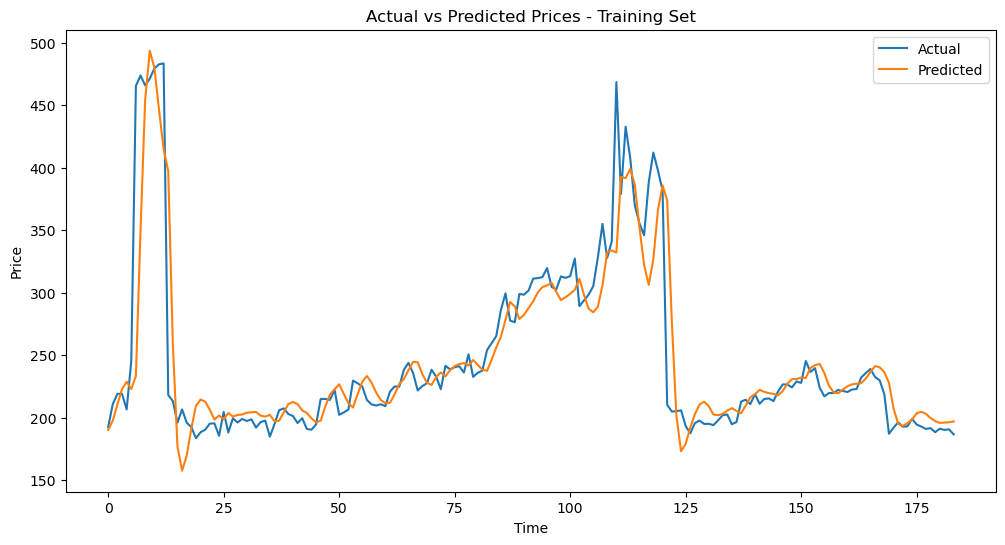

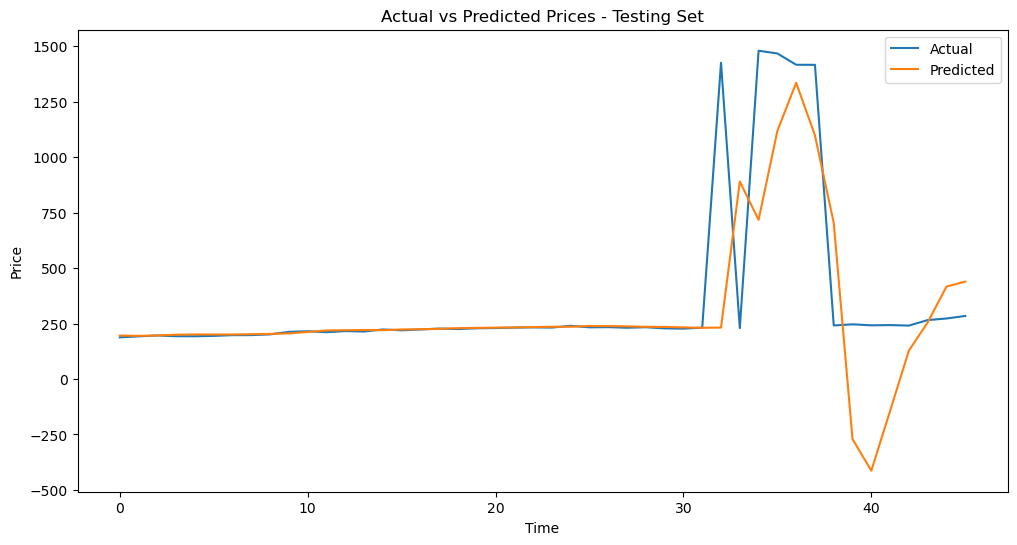

In [78]:
import matplotlib.pyplot as plt

# Plot actual vs predicted for training set
plt.figure(figsize=(12, 6))
plt.plot(y_train_actual, label='Actual')
plt.plot(y_train_pred_actual, label='Predicted')
plt.title('Actual vs Predicted Prices - Training Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot actual vs predicted for testing set
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_test_pred_actual, label='Predicted')
plt.title('Actual vs Predicted Prices - Testing Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [79]:
d

,date,price
0,2000-02-01,0.053404
1,2000-03-01,0.043292
2,2000-04-01,0.049974
3,2000-05-01,0.049490
4,2000-06-01,0.049135
...,...,...
235,2019-09-01,0.058386
236,2019-10-01,0.056683
237,2019-11-01,0.075554
238,2019-12-01,0.081035
